In [20]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import os 
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots
import pandas as pd

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

from helpers import *

device: cuda


# Check phantom analysis results

## SXR 

In [21]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_sxr_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis/metrics_diffusion_sxr_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")


Noise level: 0.05
MSE: 0.000026 +- 0.0001
SSIM: 0.996104 +- 0.0074
PSNR: 47.074031 +- 3.1666
Noise level: 0.25
MSE: 0.000124 +- 0.0001
SSIM: 0.985892 +- 0.0110
PSNR: 40.046038 +- 3.1298
Noise level: 0.5
MSE: 0.000312 +- 0.0002
SSIM: 0.971575 +- 0.0176
PSNR: 35.997982 +- 3.1973


Noise level: 0.05, procedure=True
MSE: 95.763879 +- 247.5900
SSIM: 0.981761 +- 0.0281
PSNR: 40.836958 +- 7.1251
Noise level: 0.25, procedure=True
MSE: 149.169221 +- 304.4846
SSIM: 0.970827 +- 0.0303
PSNR: 36.418206 +- 5.0711
Noise level: 0.5, procedure=True
MSE: 218.593167 +- 367.4471
SSIM: 0.956487 +- 0.0341
PSNR: 33.644113 +- 4.0949


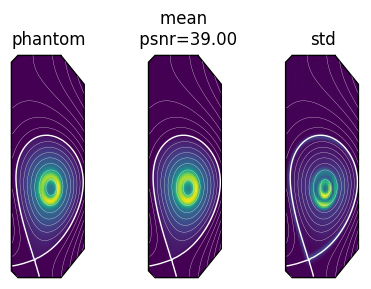

In [22]:
H, W = 120, 40

idx_to_be_plotted = 5
noise_idx=1
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis/post_means_sxr_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis/post_stds_sxr_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)

# plot using show_samples
summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom",
                              "mean \n psnr={:.2f}".format(res['psnr'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi])

## DMPX

In [23]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.1, 0.5, 1.0]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_dmpx_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis/metrics_diffusion_dmpx_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")


Noise level: 0.1
MSE: 0.000140 +- 0.0002
SSIM: 0.985921 +- 0.0133
PSNR: 41.552544 +- 5.2016
Noise level: 0.5
MSE: 0.000313 +- 0.0004
SSIM: 0.968405 +- 0.0228
PSNR: 37.330657 +- 4.6776
Noise level: 1.0
MSE: 0.000519 +- 0.0005
SSIM: 0.950079 +- 0.0297
PSNR: 34.612533 +- 4.2124


Noise level: 0.1, procedure=True
MSE: 185.582995 +- 417.6733
SSIM: 0.961540 +- 0.0411
PSNR: 36.037321 +- 6.3403
Noise level: 0.5, procedure=True
MSE: 266.889396 +- 537.4116
SSIM: 0.943303 +- 0.0470
PSNR: 33.493747 +- 5.3089
Noise level: 1.0, procedure=True
MSE: 332.750098 +- 603.4561
SSIM: 0.927450 +- 0.0496
PSNR: 31.911206 +- 4.6735


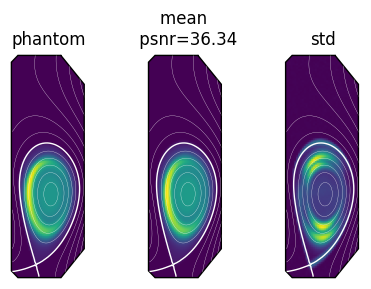

In [24]:
H, W = 120, 40

idx_to_be_plotted = 0
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis/post_means_dmpx_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis/post_stds_dmpx_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)

# plot using show_samples
summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom",
                              "mean \n psnr={:.2f}".format(res['psnr'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi])

## Pilatus, clip=False

In [25]:
noise_levels = [0.07, 0.35, 0.7]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_{noise}_clipFalse_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_{noise}_clipFalse_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        valid = df_noise[m].replace([np.inf, -np.inf], np.nan).dropna()
        n_excluded = len(df_noise) - len(valid)
        if n_excluded > 0:
            print(f"  [{m}] Excluded {n_excluded} Inf value(s)")
        print(f"{metric_labels[m]}: {valid.mean():.6f} +- {valid.std():.4f}")

Noise level: 0.07
MSE: 0.007745 +- 0.0069
SSIM: 0.746526 +- 0.1001
PSNR: 22.434715 +- 3.6742
Noise level: 0.35
MSE: 0.008031 +- 0.0071
SSIM: 0.734800 +- 0.0991
PSNR: 22.232070 +- 3.5991
Noise level: 0.7
MSE: 0.008345 +- 0.0072
SSIM: 0.722755 +- 0.0983
PSNR: 21.953298 +- 3.4166


Noise level: 0.07, procedure=True
MSE: 2558.485628 +- 3739.7752
SSIM: 0.737469 +- 0.0976
PSNR: 22.115033 +- 3.5809
Noise level: 0.35, procedure=True
MSE: 2667.607875 +- 3797.1005
SSIM: 0.724298 +- 0.0980
PSNR: 21.870449 +- 3.4965
Noise level: 0.7, procedure=True
MSE: 2760.433529 +- 3921.3117
SSIM: 0.713810 +- 0.0966
PSNR: 21.646048 +- 3.3140


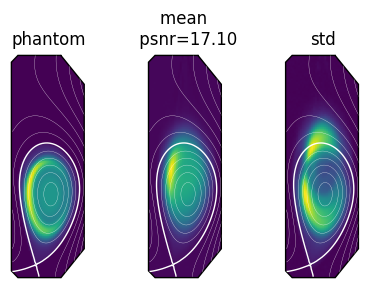

In [26]:
H, W = 120, 40

idx_to_be_plotted = 0
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis/post_means_pilatus_" + noise_ + "_clipFalse_false.npy")[idx_to_be_plotted,:], \
                        np.load("metrics_csv_phantom_analysis/post_stds_pilatus_" + noise_ + "_clipFalse_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)

# plot using show_samples
summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom",
                              "mean \n psnr={:.2f}".format(res['psnr'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi])

## Pilatus, clip=True

In [27]:
noise_levels = [0.07, 0.35, 0.7]#[0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_{noise}_clipTrue_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_{noise}_clipTrue_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        valid = df_noise[m].replace([np.inf, -np.inf], np.nan).dropna()
        n_excluded = len(df_noise) - len(valid)
        if n_excluded > 0:
            print(f"  [{m}] Excluded {n_excluded} Inf value(s)")
        print(f"{metric_labels[m]}: {valid.mean():.6f} +- {valid.std():.4f}")

Noise level: 0.07
MSE: 0.002429 +- 0.0034
SSIM: 0.911995 +- 0.0623
PSNR: 28.875968 +- 5.0366
Noise level: 0.35
MSE: 0.002623 +- 0.0034
SSIM: 0.899748 +- 0.0639
PSNR: 28.197205 +- 4.7205
Noise level: 0.7
MSE: 0.002881 +- 0.0034
SSIM: 0.888242 +- 0.0670
PSNR: 27.488870 +- 4.4200


Noise level: 0.07, procedure=True
MSE: 990.193622 +- 1942.4498
SSIM: 0.902088 +- 0.0648
PSNR: 27.467471 +- 4.6497
Noise level: 0.35, procedure=True
MSE: 1036.731899 +- 1779.0565
SSIM: 0.890181 +- 0.0644
PSNR: 26.905422 +- 4.2373
Noise level: 0.7, procedure=True
MSE: 1117.670327 +- 1887.6483
SSIM: 0.879979 +- 0.0656
PSNR: 26.403659 +- 3.9845


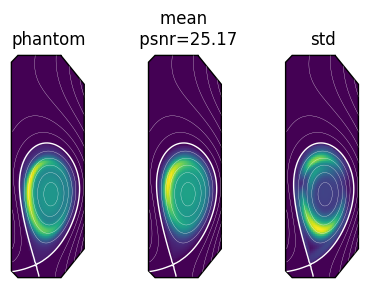

In [28]:
H, W = 120, 40

idx_to_be_plotted = 0
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis/post_means_pilatus_" + noise_ + "_clipTrue_false.npy")[idx_to_be_plotted,:], \
                        np.load("metrics_csv_phantom_analysis/post_stds_pilatus_" + noise_ + "_clipTrue_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)

# plot using show_samples
summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom",
                              "mean \n psnr={:.2f}".format(res['psnr'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi])

## Diff RD

In [39]:
noise_levels = [0.07, 0.35, 0.7]#[0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis_diffrd_correct_rdparams/metrics_diffusion_pilatus_{noise}_clipTrue_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis_diffrd_correct_rdparams/metrics_diffusion_pilatus_{noise}_clipTrue_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level
    df_noise = df_noise.copy()
    avg_vals = df_noise[metrics].mean()
    val = 3
    df_noise = df_noise[(df_noise['mse'] < avg_vals['mse'] + val*df_noise['mse'].std()) & (df_noise['mse'] > avg_vals['mse'] - val*df_noise['mse'].std())]
    df_noise = df_noise[(df_noise['ssim'] < avg_vals['ssim'] + val*df_noise['ssim'].std()) & (df_noise['ssim'] > avg_vals['ssim'] - val*df_noise['ssim'].std())]
    df_noise = df_noise[(df_noise['psnr'] < avg_vals['psnr'] + val*df_noise['psnr'].std()) & (df_noise['psnr'] > avg_vals['psnr'] - val*df_noise['psnr'].std())]

    print("number of removed outliers: ", len(results[i]) - len(df_noise))
    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    # plt.figure(figsize=(8,5))
    # plt.plot(df_noise['psnr'], label='psnr')
    # plt.xlabel('Sample Index')
    # plt.ylabel('PSNR')
    # plt.title(f'Noise Level: {df_noise["noise"].iloc[0]}')
    # plt.legend()
    # plt.show()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level
    df_noise = df_noise.copy()
    avg_vals = df_noise[metrics].mean()

    df_noise = df_noise[(df_noise['mse'] < avg_vals['mse'] + val*df_noise['mse'].std()) & (df_noise['mse'] > avg_vals['mse'] - val*df_noise['mse'].std())]
    df_noise = df_noise[(df_noise['ssim'] < avg_vals['ssim'] + val*df_noise['ssim'].std()) & (df_noise['ssim'] > avg_vals['ssim'] - val*df_noise['ssim'].std())]
    df_noise = df_noise[(df_noise['psnr'] < avg_vals['psnr'] + val*df_noise['psnr'].std()) & (df_noise['psnr'] > avg_vals['psnr'] - val*df_noise['psnr'].std())]
    print("number of removed outliers: ", len(results_procedureTrue[i]) - len(df_noise))
    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    # plt.figure(figsize=(8,5))
    # plt.plot(df_noise['psnr'], label='PSNR')
    # plt.xlabel('Sample Index')
    # plt.ylabel('PSNR')
    # plt.title(f'Noise Level, procedure=True: {df_noise["noise"].iloc[0]}')
    # plt.legend()
    # plt.show()

    

    for m in metrics:
        valid = df_noise[m].replace([np.inf, -np.inf], np.nan).dropna()
        n_excluded = len(df_noise) - len(valid)
        if n_excluded > 0:
            print(f"  [{m}] Excluded {n_excluded} Inf value(s)")
        print(f"{metric_labels[m]}: {valid.mean():.6f} +- {valid.std():.4f}")

Noise level: 0.07
number of removed outliers:  23
MSE: 0.001728 +- 0.0016
SSIM: 0.954535 +- 0.0292
PSNR: 32.871310 +- 5.9779
Noise level: 0.35
number of removed outliers:  24
MSE: 6.922276 +- 0.0017
SSIM: 0.950105 +- 0.0323
PSNR: 32.105262 +- 5.8479
Noise level: 0.7
number of removed outliers:  22
MSE: 461.943124 +- 0.0020
SSIM: 0.940930 +- 0.0356
PSNR: 30.944501 +- 5.2431


Noise level: 0.07, procedure=True
number of removed outliers:  12
MSE: 654.549378 +- 1309.4070
SSIM: 0.942291 +- 0.0415
PSNR: 30.193177 +- 5.7382
Noise level: 0.35, procedure=True
number of removed outliers:  16
MSE: 638.159842 +- 1209.6132
SSIM: 0.938047 +- 0.0425
PSNR: 29.823066 +- 5.3386
Noise level: 0.7, procedure=True
number of removed outliers:  15
MSE: 709.648444 +- 1251.2808
SSIM: 0.928317 +- 0.0447
PSNR: 28.950968 +- 4.8999


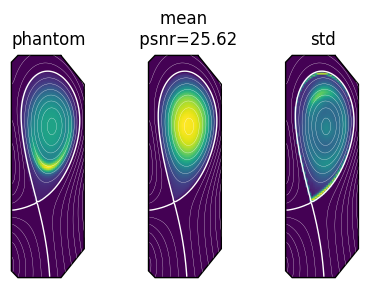

In [30]:
H, W = 120, 40

idx_to_be_plotted = 520
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis_diffrd/post_means_pilatus_" + noise_ + "_clipTrue_false.npy")[idx_to_be_plotted,:], \
                        np.load("metrics_csv_phantom_analysis_diffrd/post_stds_pilatus_" + noise_ + "_clipTrue_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)

# plot using show_samples
summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom",
                              "mean \n psnr={:.2f}".format(res['psnr'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi])